# **Explorytary Data Analysis (EDA)**
# **Web Traffic Time Series Forecasting**

-------------------------------------------------------------------------------------------

# 0. Imports

In [ ]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm

import warnings
warnings.filterwarnings("ignore")

data_dir = Path("data")

## 1. Data Loading

In [4]:
df = pd.read_csv(data_dir / "train_2.csv")
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2017-09-01,2017-09-02,2017-09-03,2017-09-04,2017-09-05,2017-09-06,2017-09-07,2017-09-08,2017-09-09,2017-09-10
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,19.0,33.0,33.0,18.0,16.0,27.0,29.0,23.0,54.0,38.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,32.0,30.0,11.0,19.0,54.0,25.0,26.0,23.0,13.0,81.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,6.0,6.0,7.0,2.0,4.0,7.0,3.0,4.0,7.0,6.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,7.0,19.0,19.0,9.0,6.0,16.0,19.0,30.0,38.0,4.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.0,16.0,19.0,9.0,20.0,23.0,28.0,14.0,8.0,7.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145063 entries, 0 to 145062
Columns: 804 entries, Page to 2017-09-10
dtypes: float64(803), str(1)
memory usage: 889.8 MB


## 2. Missing Values

In [13]:
nan_mask = df.isnull()
total_missings = nan_mask.sum().sum()
row_missings = nan_mask.any(axis=0).sum()

print(f"Total missing values: {total_missings} ({((total_missings / df.size) * 100):.2f}%)")
print(f"Total rows with missing values: {row_missings} ({((row_missings / len(df)) * 100):.2f}%)")

Total missing values: 7027348 (6.03%)
Total rows with missing values: 803 (0.55%)


In [55]:
df.iloc[:, 1:] = df.iloc[:, 1:].fillna(0)

## 3. Feature Extraction

In [14]:
def get_language(page: str) -> str:
    lang = re.search(r'_([a-z-]+)\.wikipedia\.org', page)
    return lang.group(1) if lang else "na"

def get_access_type(page: str) -> str:
    parts = page.split('_')
    return parts[-2] if len(parts) >= 2 else "na"

def get_agent_type(page: str) -> str:
    parts = page.split('_')
    return parts[-1] if len(parts) >= 1 else "na"

In [15]:
df['Language'] = df['Page'].map(get_language)
df['Access'] = df['Page'].map(get_access_type)
df['Agent'] = df['Page'].map(get_agent_type)

print(Counter(df['Language']))
print(Counter(df['Access']))
print(Counter(df['Agent']))

Counter({'en': 24108, 'ja': 20431, 'de': 18547, 'na': 17855, 'fr': 17802, 'zh': 17229, 'ru': 15022, 'es': 14069})
Counter({'all-access': 74315, 'mobile-web': 35939, 'desktop': 34809})
Counter({'all-agents': 110150, 'spider': 34913})


## 4. Data Visualization

In [ ]:
# get seperatly date columns
date_cols = df.columns[1:-3]

# calc groupped mean traffic
lang_mean = (df.groupby('Language')[date_cols].mean()).T
access_mean = (df.groupby('Access')[date_cols].mean()).T
angent_mean = (df.groupby('Agent')[date_cols].mean()).T

## 4.1 Global Traffic Trends

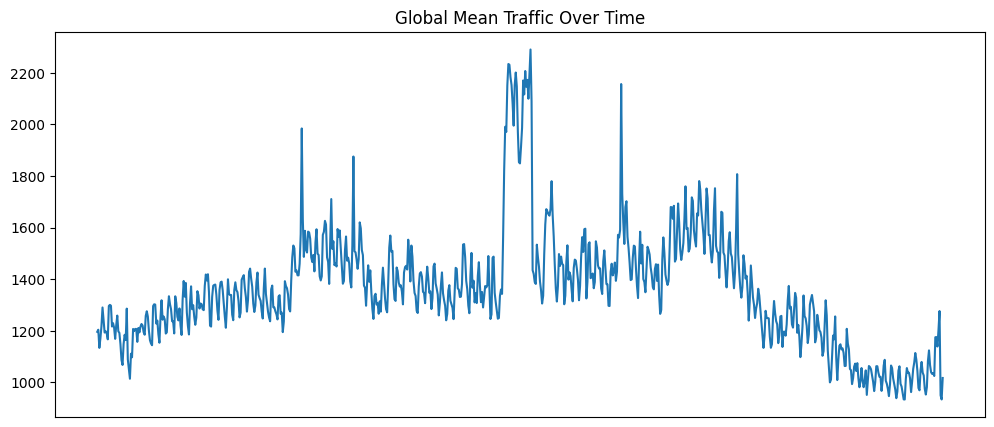

In [17]:
# global trend
global_mean = df[date_cols].mean()
plt.figure(figsize=(12,5))
plt.plot(global_mean.index, global_mean.values)
plt.title("Global Mean Traffic Over Time")
plt.xticks([])
plt.show()

## 4.2 Grouped mean traffic

In [18]:
def show_group_mean_trend(mean_groupped: pd.DataFrame, group_name: str) -> None:
    plt.figure(figsize=(8, 5))
    for col in mean_groupped.columns:
        plt.plot(mean_groupped.index, mean_groupped[col], label=col)
    
    plt.legend()
    plt.title(f"Average Views per Page by {group_name}")
    plt.ylabel("Views")
    plt.show()

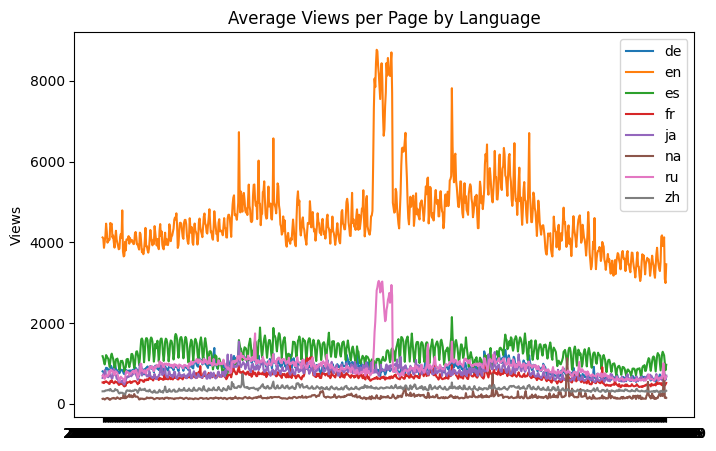

In [19]:
show_group_mean_trend(lang_mean, "Language")

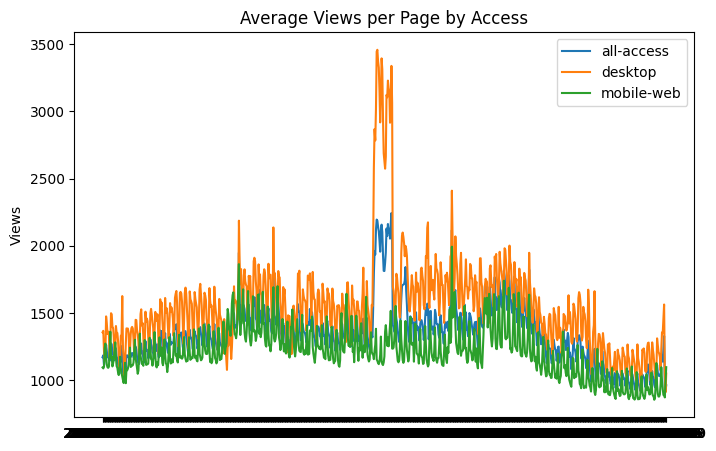

In [20]:
show_group_mean_trend(access_mean, "Access")

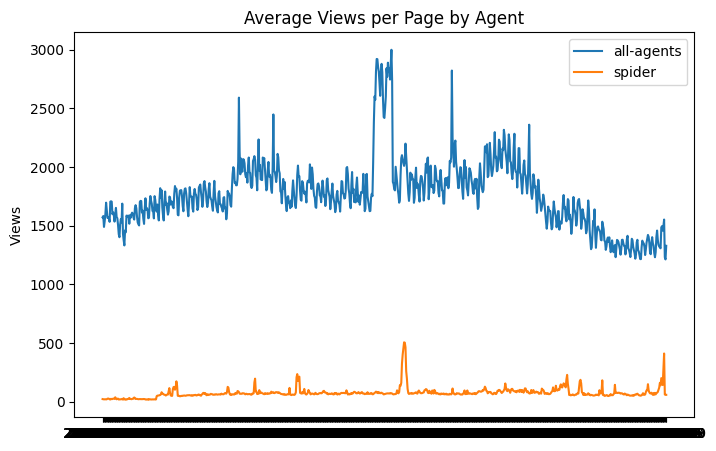

In [21]:
show_group_mean_trend(angent_mean, "Agent")

## 4.3 Distributions Visualization

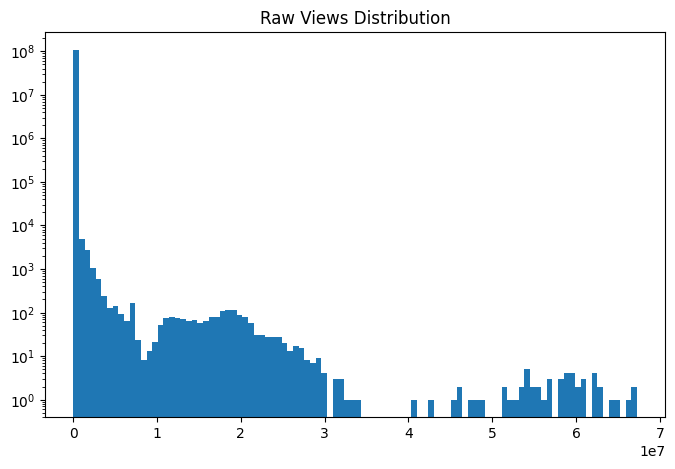

In [22]:
# log views distribution
views = df[date_cols].values.flatten()
plt.figure(figsize=(8,5))
plt.hist(views, bins=100)
plt.yscale("log")
plt.title("Raw Views Distribution")
plt.show()

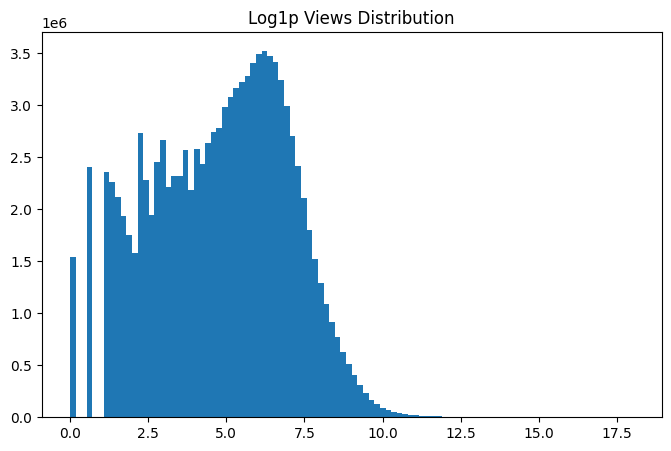

In [23]:
# log1p views distribution
plt.figure(figsize=(8,5))
plt.hist(np.log1p(views), bins=100)
plt.title("Log1p Views Distribution")
plt.show()

In [25]:
zero_ratio = (df[date_cols] == 0).mean().mean()
print("Zero ratio:", zero_ratio)

Zero ratio: 0.013227644837680307


In [50]:
# distribution shift in the end
recent_mean = df[date_cols[-60:]].mean().mean()
past_mean = df[date_cols[:-60]].mean().mean()
print("Recent shift ratio:", (recent_mean - past_mean) / past_mean)

Recent shift ratio: -0.2573886380498626


## 4.4 Regularities

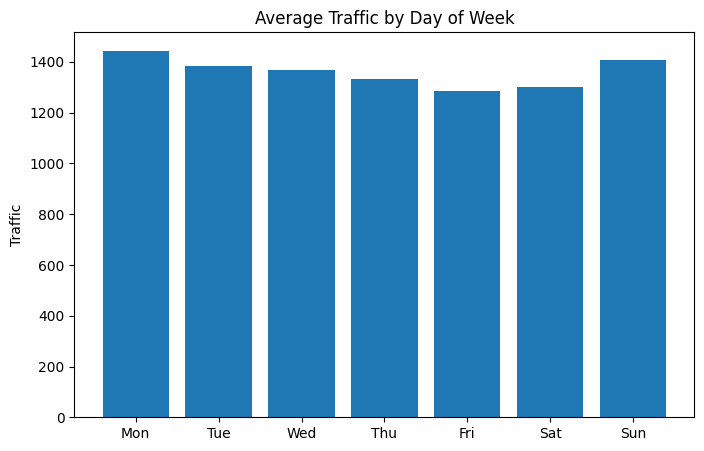

In [35]:
dates = pd.to_datetime(date_cols)
dow_mean = (global_mean.groupby(dates.dayofweek).mean())

plt.figure(figsize=(8,5))
dow = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
plt.bar(dow, dow_mean.values)
plt.title("Average Traffic by Day of Week")
plt.ylabel("Traffic")
plt.show()

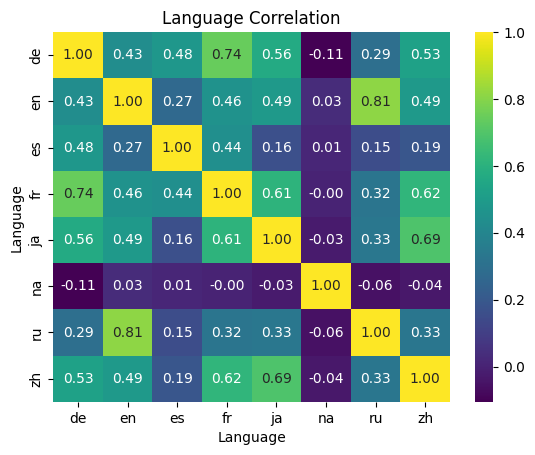

In [40]:
lang_corr = lang_mean.corr()
sns.heatmap(
    lang_corr,
    annot=True,
    fmt=".2f",
    cmap="viridis")
plt.title("Language Correlation")
plt.show()

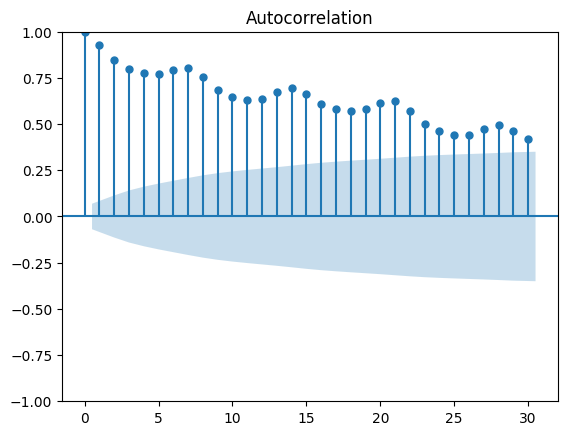

In [45]:
# lag structure?
sm.graphics.tsaplots.plot_acf(global_mean, lags=30)
plt.show()

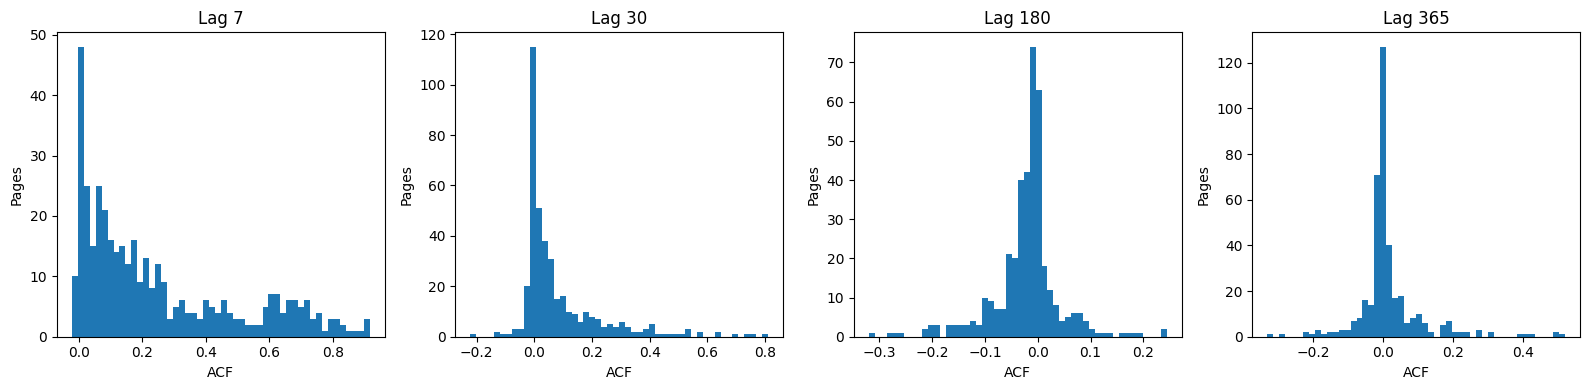

In [52]:
def lag_strength(series, nlags: int):
    if series.std() == 0:
        return 0
    return sm.tsa.stattools.acf(series, nlags=nlags)[nlags]


sample_pages = df.sample(500, random_state=42)
lags = [7, 30, 180, 365]
fig, axs = plt.subplots(1, len(lags), figsize=(4 * len(lags), 4))

for i, lag in enumerate(lags):
    lag_scores = sample_pages[date_cols].apply(
        lambda row: lag_strength(row.values, lag),
        axis=1
    )
    axs[i].hist(
        lag_scores.dropna(),
        bins=50
    )
    axs[i].set_title(f"Lag {lag}")
    axs[i].set_xlabel("ACF")
    axs[i].set_ylabel("Pages")

plt.tight_layout()
plt.show()

In [46]:
# check stationarity
result = sm.tsa.stattools.adfuller(global_mean)
print("ADF p-value:", result[1])

ADF p-value: 0.08256467605400836


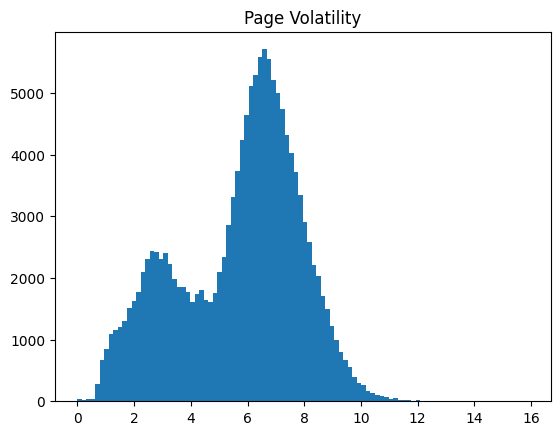

In [ ]:
# page valatility
page_std = df[date_cols].std(axis=1)
plt.hist(np.log1p(page_std), bins=100)
plt.title("Page Volatility")
plt.show()

## 5. Anomalies

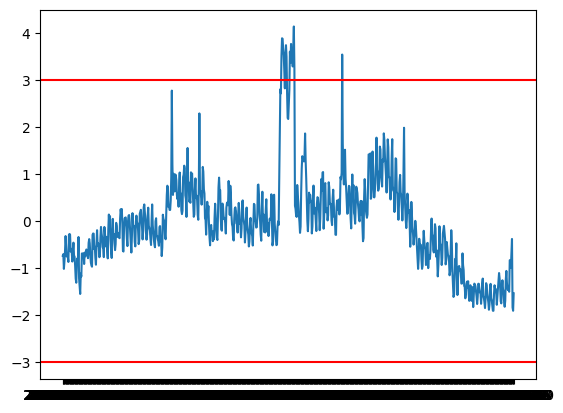

In [48]:
# look at some anomalies
# (we couldn't see every one because of averaging)
zscore = (global_mean - global_mean.mean()) / global_mean.std()
plt.plot(zscore)
plt.axhline(3, color='r')
plt.axhline(-3, color='r')
plt.show()

## 6. FFT Analysis

In [57]:
# transform to long format
id_columns = ['Page', 'Language', 'Access', 'Agent']
df_long = df.melt(id_vars=id_columns, var_name='Date', value_name='Views')
df_long['Date'] = pd.to_datetime(df_long['Date'])
df_long = df_long.sort_values(by=['Page', 'Date']).reset_index(drop=True)

## 6.1 FFT for specific page

In [61]:
def show_fft(period: np.ndarray, amplitude: np.ndarray, title: str) -> None:
    plt.figure(figsize=(10, 5))
    plt.plot(period[:100], amplitude[1:101])
    plt.xlabel("Period (days)")
    plt.ylabel("Normalized amplitude")
    plt.title(title)
    plt.xlim(1, 100)
    plt.grid()
    plt.show()

In [ ]:
# look at specific page
page = 'Guadeloupe_fr.wikipedia.org_desktop_all-agents'
ts = (
    df_long[df_long['Page'] == page]
    .sort_values('Date')['Views']
    .fillna(0)
)

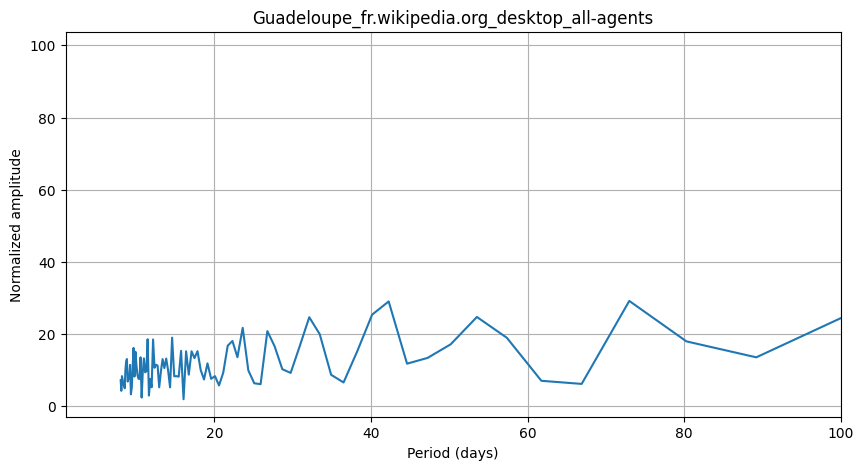

In [ ]:
y = ts.values.astype(float)
y = y - y.mean()
n = len(y)

# Fast Fourier Transform
fft = np.fft.rfft(y)
freq = np.fft.rfftfreq(n, d=1)

amp = np.abs(fft) / n
period = 1 / freq[1:]

show_fft(period, amp, page)

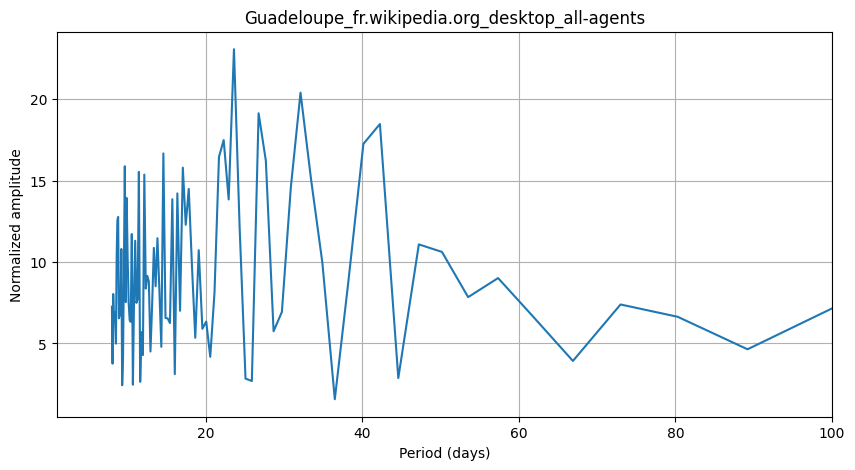

In [83]:
# detrend
y_detr = y - pd.Series(y).rolling(
    30,
    center=True,
    min_periods=1
).mean()

# Fast Fourier Transform
fft_detr = np.fft.rfft(y_detr)
freq_detr = np.fft.rfftfreq(n, d=1)

amp_detr = np.abs(fft_detr) / n
period_detr = 1 / freq_detr[1:]

show_fft(period_detr, amp_detr, page)

## 6.2 FFT for whole dataset

In [84]:
# aggregated fft

date_cols = [col for col in df.columns if col.startswith('201')]
global_sum = df[date_cols].sum(axis=0).values.astype(float)
global_median = df[date_cols].median(axis=0).values.astype(float)

In [88]:
def analyze_global_fft(y_raw, title):
    n = len(y_raw)
    
    # detrand
    y_detr = y_raw - pd.Series(y_raw).rolling(window=30, center=True, min_periods=1).mean().values
    
    # Fast Fourier Transform
    fft_res = np.fft.rfft(y_detr)
    freq = np.fft.rfftfreq(n, d=1)
    
    amp = np.abs(fft_res) / n
    period = 1 / freq[1:]
    amp = amp[1:]
    
    mask = (period >= 2) & (period <= 400)
    
    plt.figure(figsize=(14, 6))
    plt.plot(period[mask], amp[mask], color='#1f77b4', linewidth=2, label='FFT Spectrum')
    plt.axvline(x=7, color='red', linestyle='--', alpha=0.8, label='Week (7 days)')
    plt.axvline(x=31, color='orange', linestyle='--', alpha=0.8, label='Month (31 days)')
    if period[mask].max() >= 180:
        plt.axvline(x=180, color='yellow', linestyle='--', alpha=0.8, label='Half of a year (180 days)')
    if period[mask].max() >= 365:
        plt.axvline(x=365, color='green', linestyle='--', alpha=0.8, label='Year (365 days)')
        
    plt.title(f'Global frequencies spectrum ({title})', fontsize=14)
    plt.xlabel('Period (days)', fontsize=12)
    plt.ylabel('Normalized amplitude', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(fontsize=11)
    plt.xlim(2, 400)
    plt.show()

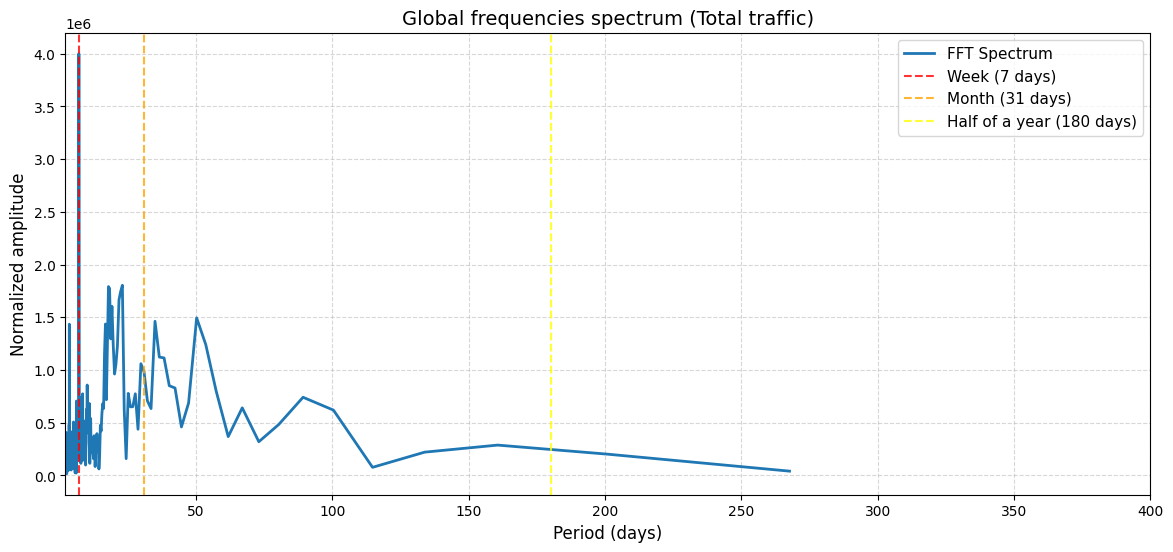

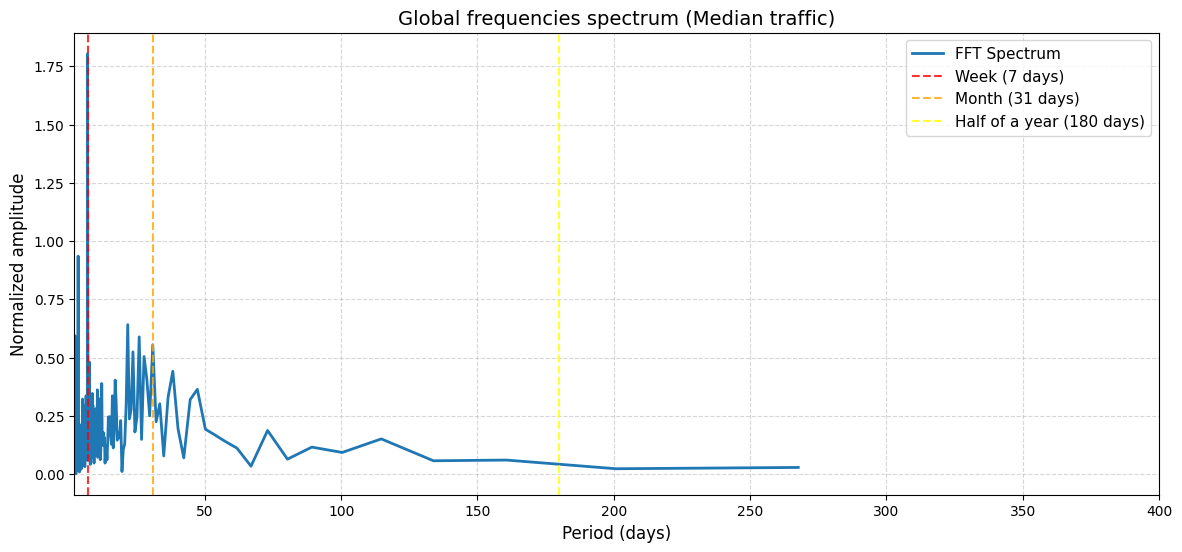

In [89]:
analyze_global_fft(global_sum, "Total traffic")
analyze_global_fft(global_median, "Median traffic")